# Homework 2
Kai Rothe, Karim Zaghw

In [1]:
from IPython.display import display, Math, Latex

# Libraries you might need
from matplotlib import pyplot as plt
%matplotlib inline

import numpy as np
import seaborn as sns

In [2]:
# You can use this function for plotting raster plots (spikes), or you can use your own defined function
def raster(event_times_list, color='k', t_min= 0., t_max=10., ax=None):
    """
    Creates a raster plot
    Parameters
    ----------
    event_times_list : iterable
                       a list of event time iterables
    color : string
            color of vlines
    Returns
    -------
    ax : an axis containing the raster plot
    https://scimusing.wordpress.com/2013/05/06/making-raster-plots-in-python-with-matplotlib/
    """
    if ax is None:
        ax = plt.gca()
    for ith, trial in enumerate(event_times_list):
        ax.vlines(trial, ith + .5, ith + 1.5, color=color)
    ax.set_ylim(.5, len(event_times_list) + .5)
    ax.set_yticks([])
    ax.set_ylabel('Spike train')
    ax.set_xlim((t_min, t_max))
    ax.set_xlabel('Time [s]')
    return ax

__1. Generation of inhomogeneous Poisson process__. Consider an inhomogeneous Poisson process with instanteneous firing rate $\lambda: \mathbb{R} \to \mathbb{R}^+$ such that $\lambda(t) = \lambda_{max} (t-1)^2$, where $t$ is measured in seconds, $\lambda$ in Herz [Hz].

In exercise (a) - (d), generate $N = 100$ spike trains for $\lambda_{max} = 100$ Hz. Plot the raster plot, the numeric approximation of the rate and for comparison the analytic rate given in the exercise.
A numeric approximation of the rate $\tilde\lambda$ can be computed by binning the data into 100 bins on the interval $[t_{min}, t_{max}]$ for each spike train (bin size $\Delta t = \frac{t_{max}-t_{min}}2$) and computing the number of spikes in all spike trains within the bin, devided by $N$ and the bin size: $\tilde\lambda = \frac{\#spikes}{N \cdot \Delta t}$.

*Hint: Compute the analytical integral of the rate function. Write a function both for the rate function and its integral.*

The integral of $\lambda(t) = \lambda_{\text{max}} (t-1)^2$ can be derived as follows:

$$
\int_{t_{min}}^t \lambda(t') \, dt' = \int_{t_{min}}^t \lambda_{\text{max}} (t'-1)^2 \, dt' = \lambda_{\text{max}} \int_{t_{min}}^t (t'-1)^2 \, dt' = \lambda_{\text{max}} \frac{1}{3} (t-1)^3 |_{t_{min}}^t = \frac{\lambda_{\text{max}}}{3} \left[ (t-1)^3 - (t_{min}-1)^3 \right]
$$

In [3]:
def rate(t, rate_max):
    return rate_max * (t - 1)**2

def indefinite_integral(t, rate_max):
    return rate_max / 3 * (t-1)**3

def rate_integral(t_min, t_max, rate_max):
    return indefinite_integral(t_max, rate_max) - indefinite_integral(t_min, rate_max)

rate_max = 100
n_trials = 100
t_min = 0
t_max = 2
bins_count = np.linspace(t_min, t_max, 101)
bin_size = bins_count[1] - bins_count[0]

__a) Temporal distribution method:__ As in the lecture: first find number of spikes $k$ by drawing from Poisson distribution with parameter $\mu = \int_{t_{min}}^{t_{max}} \lambda(t) dt $, and then draw spike times using a density function $\lambda(t)/\mu$. _(2 points)_

*Hint: Choose an appropriate method for drawing from an arbitrary probability density, e.g., rejection sampling.*

In [4]:
# Compute the total rate integral (mu)
mu = rate_integral(t_min, t_max, rate_max)

# Generate the number of spikes k for each trial
spike_counts = np.random.poisson(mu, n_trials)

# Generate spike times using rejection sampling
spike_times = []
for trial in range(n_trials):
    trial_spike_times = []
    while len(trial_spike_times) < spike_counts[trial]:
        t_candidate = np.random.uniform(t_min, t_max)
        acceptance_prob = rate(t_candidate, rate_max) / rate_max # rate_max upper bound of \lambda(t)
        if np.random.uniform(0, 1) <= acceptance_prob:
            trial_spike_times.append(t_candidate)
    spike_times.append(sorted(trial_spike_times))

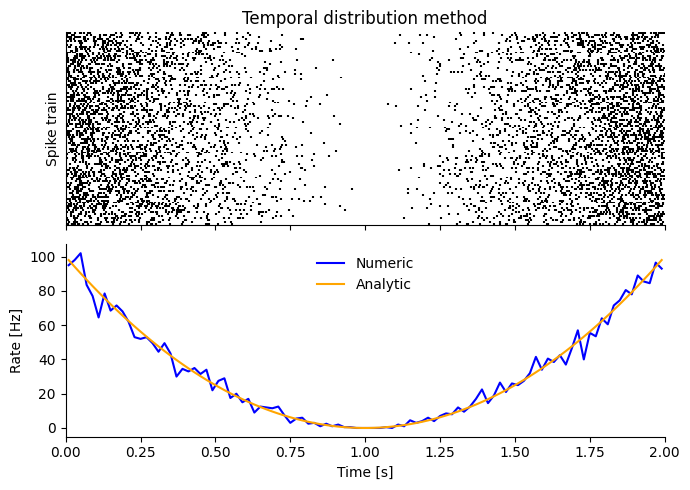

In [5]:
# plot
# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

# Raster plot
raster(spike_times, ax=axes[0], color='k', t_min=t_min, t_max=t_max)
axes[0].set_title("Temporal distribution method")
axes[0].set_xlabel("")

# Numeric approximation of the rate
spike_counts_per_bin = np.histogram(np.hstack(spike_times), bins=bins_count)[0]
numeric_rate = spike_counts_per_bin / (n_trials * bin_size)

# Analytic rate
time_points = (bins_count[:-1] + bins_count[1:]) / 2
analytic_rate = rate(time_points, rate_max)

# Plot numeric and analytic rates
axes[1].plot(time_points, numeric_rate, label="Numeric", color="blue")
axes[1].plot(time_points, analytic_rate, label="Analytic", color="orange")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Rate [Hz]")
axes[1].legend(frameon=False, loc="upper center")

sns.despine()

plt.tight_layout()
plt.show()

Numeric and analytic rate overlap, validating our implementation. 

__b) Bernoulli method:__ Discretize time into $m$ bins. For each bin $j = 1, \ldots, m$ draw a sample $k_i$ from a Poisson spike count distribution in that bin ( Poisson distribution with the parameter equal to integral of the $\lambda(t)$ over the bin). Generate a single spike in each bin with $k_i > 0$ drawing its time-stamp from uniform distribution within this bin. Generate rasters and estimated rate for $m = 10, \: 100, \: 1000, \: 10000.$ _(2 points)_

*Note: The bin count for computing a numerical approximation of the rate is still the same as above.*

In [6]:
# Function to generate spike trains using the Bernoulli method
def bernoulli_method(m, rate_max, t_min, t_max, n_trials):
    bin_edges = np.linspace(t_min, t_max, m + 1)
    spike_times = []

    for trial in range(n_trials):
        trial_spike_times = []
        for j in range(m):
            # Compute the integral of the rate function over the bin
            bin_rate = rate_integral(bin_edges[j], bin_edges[j + 1], rate_max)
            # Draw a sample from the Poisson distribution
            k_i = np.random.poisson(bin_rate)
            if k_i > 0:
                # Generate a single spike time uniformly within the bin
                spike_time = np.random.uniform(bin_edges[j], bin_edges[j + 1])
                trial_spike_times.append(spike_time)
        spike_times.append(sorted(trial_spike_times))
    return spike_times

m_values = [10, 100, 1000, 10000]
results = {m: bernoulli_method(m, rate_max, t_min, t_max, n_trials) for m in m_values}

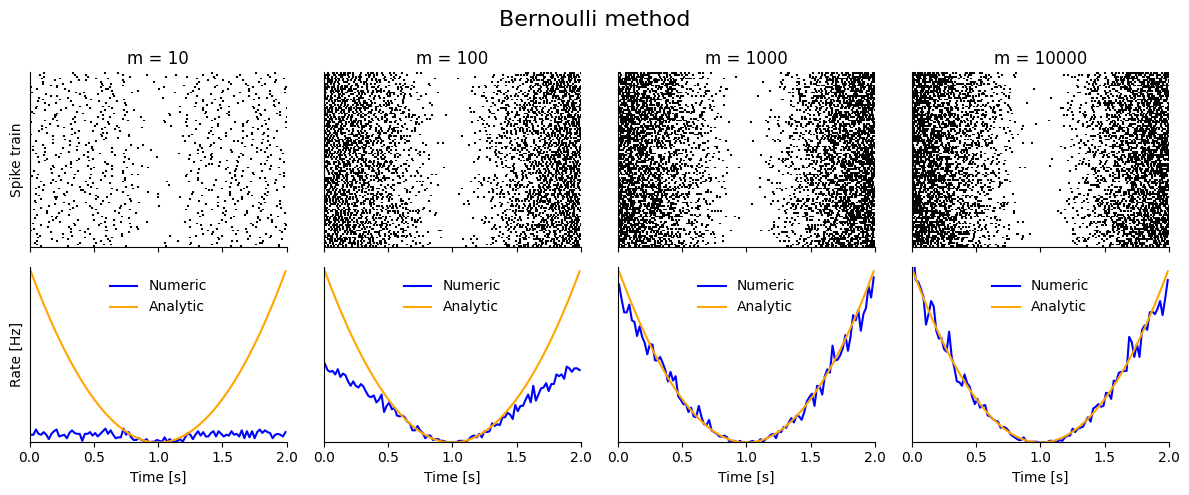

In [7]:
# Create a figure with one subplot for each m_value
fig, axes = plt.subplots(2, len(m_values), figsize=(3 * len(m_values), 5), sharey=True, sharex=True)

# Plot raster plots for each m_value
for i, m in enumerate(m_values):
    raster(results[m], ax=axes[0, i], color='k', t_min=t_min, t_max=t_max)
    axes[0, i].set_title(f"m = {m}")
    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel("")

    # Numeric approximation of the rate
    spike_counts_per_bin = np.histogram(np.hstack(results[m]), bins=bins_count)[0]
    numeric_rate = spike_counts_per_bin / (n_trials * bin_size)
    
    # Analytic rate
    time_points = (bins_count[:-1] + bins_count[1:]) / 2
    analytic_rate = rate(time_points, rate_max)

    # Plot numeric and analytic rates
    axes[1, i].plot(time_points, numeric_rate, label="Numeric", color="blue")
    axes[1, i].plot(time_points, analytic_rate, label="Analytic", color="orange")
    axes[1, i].set_xlabel("Time [s]")
    axes[1, i].legend(frameon=False, loc="upper center")

axes[0, 0].set_ylabel("Spike train")
axes[1, 0].set_ylabel("Rate [Hz]")
sns.despine()
plt.suptitle("Bernoulli method", fontsize=16)
plt.tight_layout()
plt.show()

Only for a high enough number of bins $m$ does the numerical rate converge to the analytical solution, since else the underlying assumption of the Bernoulli method with one spike per bin does not hold. 

__c) Thinning method:__ First generate a spike train from a Poisson process of rate $\lambda_{max}$ and then iterate through all spikes $l = 1, \ldots, k$ and randomly delete them with probability $1 - \lambda(t^\star_l) /\lambda_{max}$, where $t^\star_l$ is a time point of the $l$-th spike (before thinning). _(2 points)_

In [8]:
def poisson_spike_train(tau, t_min, t_max, n_trials):
    spike_trains : list[list[float]] = []
    
    for i in range(n_trials):
        spike_train = []

        # Generate the interspike interval
        delta_t = np.random.exponential(tau, 1)
        t_next = t_min + delta_t
        
        while t_next <= t_max:
            # Append the new spike time to the list
            spike_train.append(t_next)

            # Generate the interspike interval
            delta_t = np.random.exponential(tau, 1)
            t_next = spike_train[-1] + delta_t

        spike_trains.append(spike_train)
        
    return spike_trains

In [9]:
# Generate a spike train from a Poisson process of rate lambda_max
tau = 1 / rate_max 
spike_trains = poisson_spike_train(tau, t_min, t_max, n_trials)

# Perform thinning
spike_times : list[list[float]] = []
for spike_train in spike_trains:
    thinned_spike_train = []
    
    for t_star in spike_train:
        acceptance_prob = rate(t_star, rate_max) / rate_max  # Calculate acceptance probability
        if np.random.uniform(0, 1) <= acceptance_prob:
            thinned_spike_train.append(t_star)
    
    thinned_spike_train = sorted(thinned_spike_train)
    spike_times.append(thinned_spike_train)

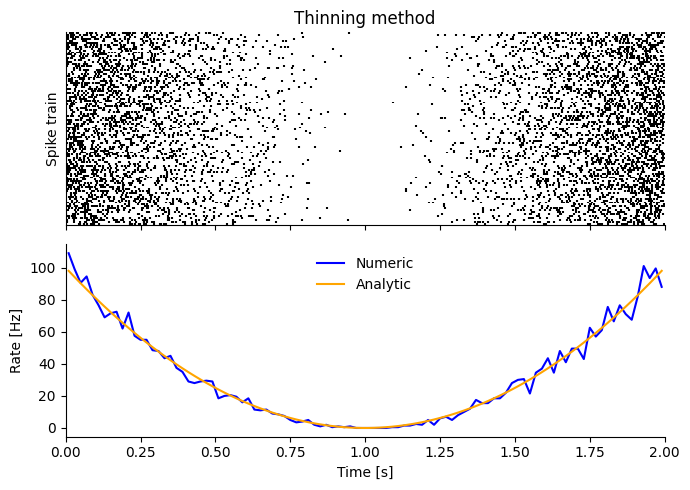

In [10]:
# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

# Raster plot
raster(spike_times, ax=axes[0], color='k', t_min=t_min, t_max=t_max)
axes[0].set_title("Thinning method")
axes[0].set_xlabel("")

# Numeric approximation of the rate
spike_counts_per_bin_and_trial = [np.histogram(spike_times_of_trial, bins=bins_count)[0] for spike_times_of_trial in spike_times]
spike_counts_per_bin = np.array(spike_counts_per_bin_and_trial).sum(axis=0)
numeric_rate = spike_counts_per_bin / (n_trials * bin_size)

# Analytic rate
time_points = (bins_count[:-1] + bins_count[1:]) / 2
analytic_rate = rate(time_points, rate_max)

# Plot numeric and analytic rates
axes[1].plot(time_points, numeric_rate, label="Numeric", color="blue")
axes[1].plot(time_points, analytic_rate, label="Analytic", color="orange")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Rate [Hz]")
axes[1].legend(frameon=False, loc="upper center")

sns.despine()

plt.tight_layout()
plt.show()

Numerical and analytical rate overlap, validating our implementation.

__d) Renewal and time rescaling method:__ Compute $\mu(t) = \int_{t_{min}}^t \lambda(s) ds$. Generate a spike train for a homogeneous Poisson process with rate $1$ on an interval $[0,\mu(t_{max})]$ (using inter-spike interval distribution as in the previous homework). Resulting spike times we call $s_l^\star$. We can then find corresponding pre-images $t_l^\star = \mu^{-1}(s_l^\star) \in [t_{min},t_{max}].$ _(2 points)_

Hint: Options for inverting functions:
- Invert $\mu(t)$ analytically and write a function. Of course, you can use any tools that you want. Remember to write your solution concisely including necessary intermediate steps.*
- You can also use "sympy" library to create symbolic equations and then find the inverse function using those symbolic equations _(2 points)_
- To find the inverse of a polynomial function at a specific value you can use function np.roots (https://docs.scipy.org/doc/numpy/reference/generated/numpy.roots.html ). You will need a real root within the interval $[t_{min},t_{max}]$.

**Answer:**

Previously, we derived
$$
\mu(t) = \int_{t_{min}}^t \lambda(t') \, dt' = \frac{\lambda_{\text{max}}}{3} \left[ (t-1)^3 - (t_{min}-1)^3 \right].
$$
Thus, for $s = \mu(t)$,
$$
t = \mu^{-1}(s) = \left(\frac{3 s}{\lambda_{\text{max}}} + (t_{min}-1)^3\right)^{\frac{1}{3}} + 1.
$$

In [11]:
def mu_inv(s, rate_max):
    """
    Computes the inverse of the function mu(t) = \int_{t_min}^t \lambda(t') dt'
    """
    return np.cbrt(3 * s / rate_max + (t_min - 1)**3) + 1

# Compute mu(t_max)
mu_t_max = rate_integral(t_min, t_max, rate_max)

# Generate a spike train for a homogeneous Poisson process with rate 1
s_stars = poisson_spike_train(1, t_min, mu_t_max, n_trials)

# Find corresponding pre-images t_l^star = mu^{-1}(s_l^star)
spike_times = [mu_inv(np.array(s_star), rate_max) for s_star in s_stars]

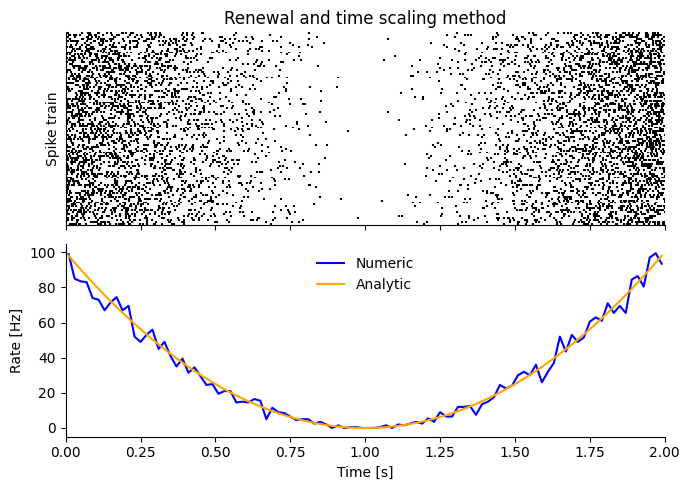

In [12]:
# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

# Raster plot
raster(spike_times, ax=axes[0], color='k', t_min=t_min, t_max=t_max)
axes[0].set_title("Renewal and time scaling method")
axes[0].set_xlabel("")

# Numeric approximation of the rate
spike_counts_per_bin_and_trial = [np.histogram(spike_times_of_trial, bins=bins_count)[0] for spike_times_of_trial in spike_times]
spike_counts_per_bin = np.array(spike_counts_per_bin_and_trial).sum(axis=0)
numeric_rate = spike_counts_per_bin / (n_trials * bin_size)

# Analytic rate
time_points = (bins_count[:-1] + bins_count[1:]) / 2
analytic_rate = rate(time_points, rate_max)

# Plot numeric and analytic rates
axes[1].plot(time_points, numeric_rate, label="Numeric", color="blue")
axes[1].plot(time_points, analytic_rate, label="Analytic", color="orange")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Rate [Hz]")
axes[1].legend(frameon=False, loc="upper center")

sns.despine()

plt.tight_layout()
plt.show()

Again numerical and analytical rate overlap.

__2. Variance of the firing rate a)__. Determine the variance of the firing rate (across the bins) using $b = 10, \: 50, \:100$ bins from spike trains generated by method 1.a) using the law of total variance  _(2 points)_

**Answer:**

In the lecture, we proved
$$ \text{Var}\left( \lambda_i \right) \approx \frac{\text{Var}\left( N_i \right)}{\Delta t^2} - \frac{N}{T \cdot \Delta t} $$
for a bin indexed by $i$ with $N_i$ spike counts and a duration of $\Delta t$. $N$ denotes the total number of spikes and $T$ the total time of a trial.

In [ ]:
def rate_var(spike_times, N, t_max, t_min, bin_size):
    """
    Approximate the variance of the rate
    """
    spike_counts_per_bin = np.array([np.histogram(spike_times_per_trial, bins=bins_count)[0] for spike_times_per_trial in spike_times]) # n_trials x n_bins
    spike_count_var = np.var(spike_counts_per_bin, axis = -1)
    T = t_max - t_min
    return spike_count_var / bin_size**2 - N / (T * bin_size)

# compute and print my solution
rate_max = 100
n_trials = 100000
t_min = 0
t_max = 2

print("Variance of the rate for different bin sizes b (Average ± SEM over trials):")

n_bins = [100, 50, 10]
for n_bin in n_bins:
    # generate spike trains with 1.a)
    bins_count = np.linspace(t_min, t_max, n_bin + 1)
    bin_size = bins_count[1] - bins_count[0]
    
    mu = rate_integral(t_min, t_max, rate_max)
    spike_counts = np.random.poisson(mu, n_trials)

    spike_times = []
    for trial in range(n_trials):
        trial_spike_times = []
        while len(trial_spike_times) < spike_counts[trial]:
            t_candidate = np.random.uniform(t_min, t_max)
            acceptance_prob = rate(t_candidate, rate_max) / rate_max # rate_max upper bound of \lambda(t)
            if np.random.uniform(0, 1) <= acceptance_prob:
                trial_spike_times.append(t_candidate)
        spike_times.append(sorted(trial_spike_times))
    
    # compute the variance of the rate 
    rate_variance = rate_var(spike_times, spike_counts, t_max, t_min, bin_size)

    mean_rate_variance = np.mean(rate_variance)
    SEM_rate_variance = np.std(rate_variance) / np.sqrt(n_trials)
    print(f"b = {n_bin}: Var(λ) = {mean_rate_variance:.2f} ± {SEM_rate_variance:.2f}")

Variance of the rate for different bin sizes b (Average ± SEM over trials):
b = 1000: Var(λ) = 872.62 ± 3.31
b = 100: Var(λ) = 872.21 ± 1.38
b = 50: Var(λ) = 872.66 ± 1.18
b = 10: Var(λ) = 827.74 ± 0.95


After averaging over 100.000 trials, we obtain a rate variance of around Var(λ) $approx$ 872 ± 2. For too small number of bins ($b = 10$), the estimation is biased towards lower values since the discritization is too course and thus our discrete approximation of the continously varying rate invalid. 

__2. Variance of the firing rate b)__. Compare results from 2.a) with analytical variance of the rate. To compute the analytical variance use the true formula for the time-dependent rate $\lambda(t) = \lambda_{max} (t-1)^2$ and treat it as a random variable for the time $t$ uniformly distributed in $[t_{min},t_{max}]$. \\
_(2 points)_

Assuming $t \sim U(t_{min}, t_{max}) = \frac{1}{t_{max}-t_{min}} = \frac{1}{2}$:

\begin{equation*}
\begin{split}
E(\lambda) 
&= \int_{t_{min}}^{t_{max}} \lambda \cdot U(t_{min}, t_{max}) \; dt \\
&= \int_{t_{min}}^{t_{max}} \lambda_{max} (t-1)^2 \cdot \frac{1}{t_{max}-t_{min}} \; dt \\
&= \frac{\lambda_{max}}{t_{max}-t_{min}} \int_{t_{min}}^{t_{max}} (t-1)^2 \; dt \\
&= \frac{\lambda_{max}}{t_{max}-t_{min}} \frac{1}{3} \left[ (t_{max}-1)^3 - (t_{min}-1)^3 \right] \\
&= \frac{\lambda_{max}}{2} \frac{1}{3} \left[(1)^3 - (-1)^3 \right]  \\
&= \frac{\lambda_{max}}{2} \frac{1}{3} \cdot 2 \\
&= \frac{\lambda_{max}}{3}, \\
\end{split}
\end{equation*}

substituting $t_{max} = 2$, $t_{min} = 0$ and $\lambda_{max} = 100$. Then

\begin{equation*}
\begin{split}
Var(\lambda)
&= \int_{t_{min}}^{t_{max}} \left[ \lambda - E\left(\lambda\right) \right]^2 \cdot U(t_{min}, t_{max}) \; dt \\
&= \frac{1}{t_{max}-t_{min}} \int_{t_{min}}^{t_{max}} \left[\lambda_{max} (t-1)^2 - \frac{\lambda_{max}}{3} \right]^2 \; dt \\
&= \frac{\lambda_{max}^2}{t_{max}-t_{min}} \int_{t_{min}}^{t_{max}} \left[ (t-1)^2 - \frac{1}{3}\right]^2 \; dt  \\
&= \frac{\lambda_{max}^2}{t_{max}-t_{min}} \int_{t_{min}}^{t_{max}} (t-1)^4 - \frac{2}{3}(t-1)^2 + \frac{1}{9} \; dt \\
&= \frac{\lambda_{max}^2}{t_{max}-t_{min}} \left[\frac{(t-1)^5}{5} - \frac{2}{9}(t-1)^3 + \frac{t}{9} \right]_{t = t_{min}}^{t_{max}} \\
&= \frac{\lambda_{max}^2}{t_{max}-t_{min}} \left[\frac{(t_{max}-1)^5 - (t_{min}-1)^5}{5} - \frac{2}{9}\left((t_{max}-1)^3 - (t_{min}-1)^3 \right) + \frac{t_{max} - t_{min}}{9} \right] \\
&= \frac{\lambda_{max}^2}{2} \left[\frac{2}{5} - \frac{4}{9} + \frac{2}{9} \right] \\
&= \frac{\lambda_{max}^2}{2} \frac{8}{45} \\
&= \lambda_{max}^2 \frac{4}{45}\\
&= 888.89.
\end{split}
\end{equation*}

We obtain a different analytic result, than we estimated numerically. TODO: why?